<a href="https://colab.research.google.com/github/1G4S/mechanical-processing/blob/main/AnalizaKorelacyjna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Analiza korelacyjna EDA

1. Konfiguracja

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

2. Definicja funkcji analizującej dane

In [2]:
def perform_eda(filepath='dane_obrobka_cnc.csv'):
    print("Wczytywanie danych...")
    df = pd.read_csv(filepath)

    # 1. OBSŁUGA ANOMALII
    # Błędy czujnika zastępujemy wartością Nan, żeby zapobiec popsuciu korelacji
    df_clean = df.copy()
    df_clean['Temp_Chlodziwa_Mean_C'] = df_clean['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    # Odrzucamy kolumny z ID
    cols_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia', 'Klasa_Jakosci']
    df_numeric = df_clean.drop(columns=cols_to_drop)

    # 2. MACIERZ KORELACJI
    print("Generowanie macierzy korelacji...")
    plt.figure(figsize=(12, 10))
    corr_matrix = df_numeric.corr(method='pearson')

    # Tworzenie maski dla górnego trójkąta (aby wykres był czytelniejszy)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

    plt.title('Macierz Korelacji Pearsona Zmiennych Procesowych', fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig('macierz_korelacji.png')
    plt.show()

    # 3. WIZUALIZACJA ZALEŻNOŚCI FIZYCZNYCH
    print("Generowanie wykresów zależności...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Wykres A: Wpływ zużycia narzędzia na wibracje (Nieliniowość)
    sns.scatterplot(data=df_clean, x='Zuzycie_Narzedzia_VB', y='Wibracje_Wrzeciona_RMS_g',
                    alpha=0.3, ax=axes[0], color='crimson')
    axes[0].set_title('A: Wpływ Zużycia Ostrza na Wibracje')
    axes[0].set_xlabel('Zużycie Narzędzia VB [mm]')
    axes[0].set_ylabel('Wibracje RMS [g]')

    # Wykres B: Zależność posuwu i chropowatości (Model kinematyczny)
    sns.scatterplot(data=df_clean, x='Posuw_f', y='Chropowatosc_Ra',
                    hue='Klasa_Jakosci', palette={'OK': 'green', 'Do_Poprawy': 'orange', 'Zlom': 'red'},
                    alpha=0.5, ax=axes[1])
    axes[1].set_title('B: Wpływ Posuwu na Chropowatość Ra')
    axes[1].set_xlabel('Posuw f [mm/obr]')
    axes[1].set_ylabel('Chropowatość Ra [µm]')

    # Wykres C: Zużycie narzędzia w funkcji wyprodukowanych sztuk (Cykl życia z rozkładu Weibulla)
    # Wybieramy jedno losowe narzędzie (np. narzędzie nr 3)
    df_tool_3 = df_clean[df_clean['ID_Narzedzia'] == 3]
    sns.lineplot(data=df_tool_3, x='ID_Czesci', y='Zuzycie_Narzedzia_VB',
                 ax=axes[2], color='navy', linewidth=2)
    axes[2].set_title('C: Krzywa Zużycia Narzędzia nr 3 w czasie')
    axes[2].set_xlabel('Kolejna wyprodukowana sztuka (ID)')
    axes[2].set_ylabel('Zużycie Narzędzia VB [mm]')

    plt.tight_layout()
    plt.savefig('wykresy_eda.png')
    plt.show()

    print("EDA zakończone. Wykresy zapisane jako pliki PNG.")

3. Uruchomienie analizy

Wczytywanie danych...
Generowanie macierzy korelacji...


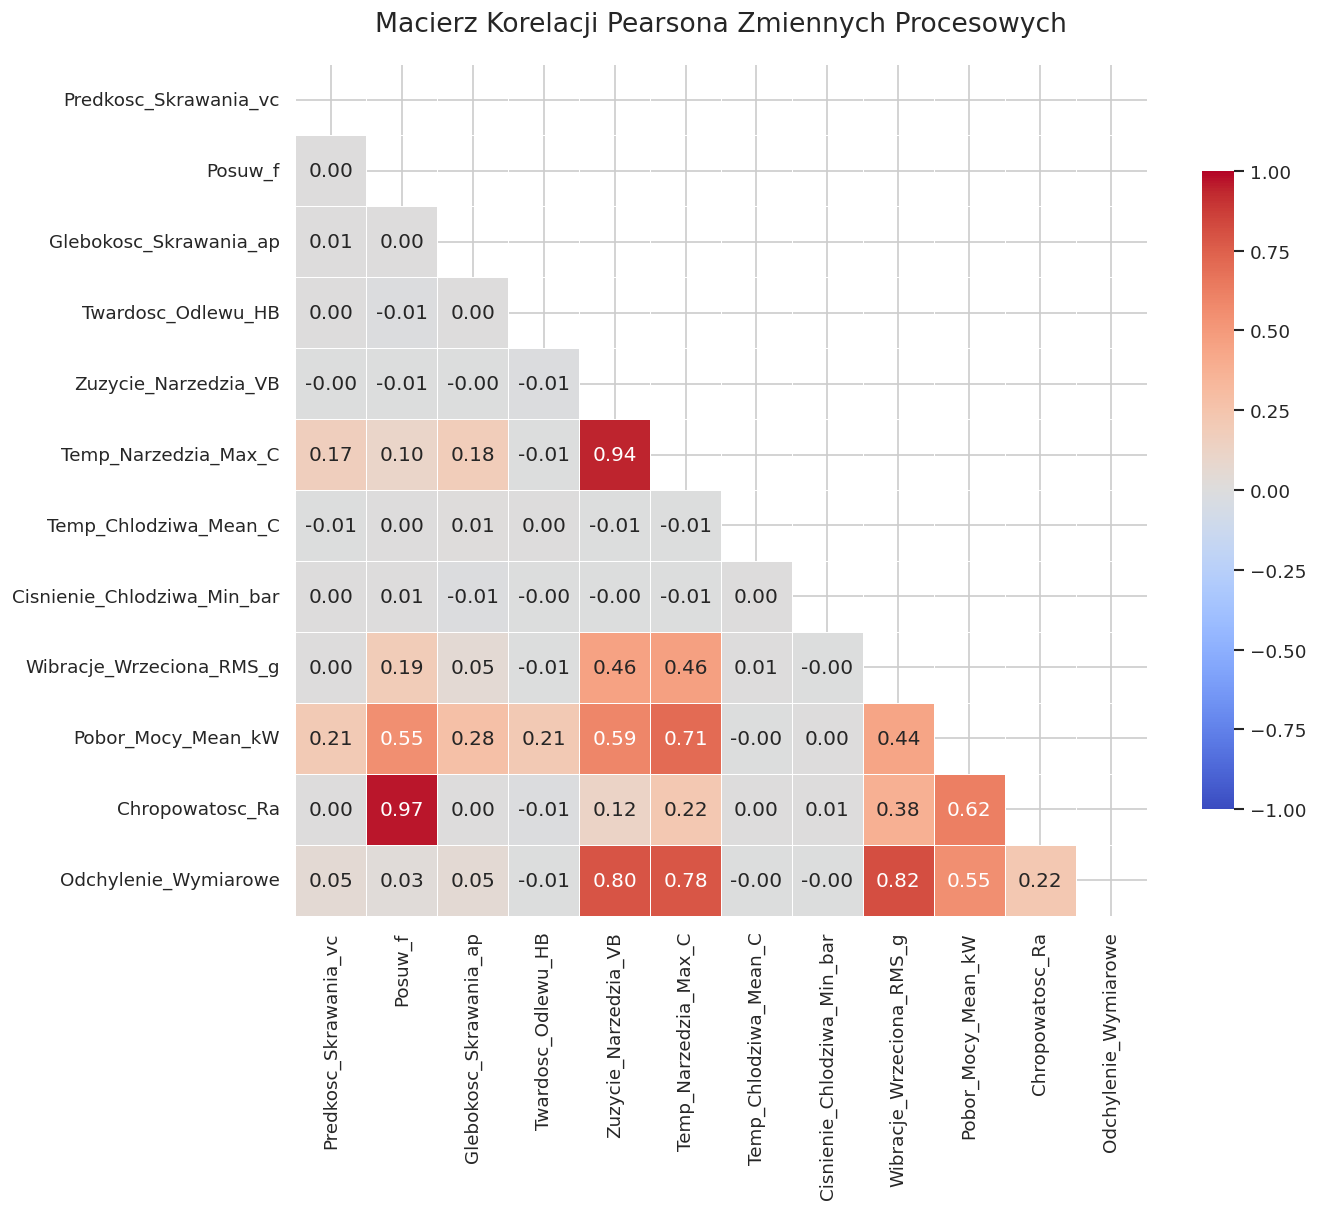

Generowanie wykresów zależności...


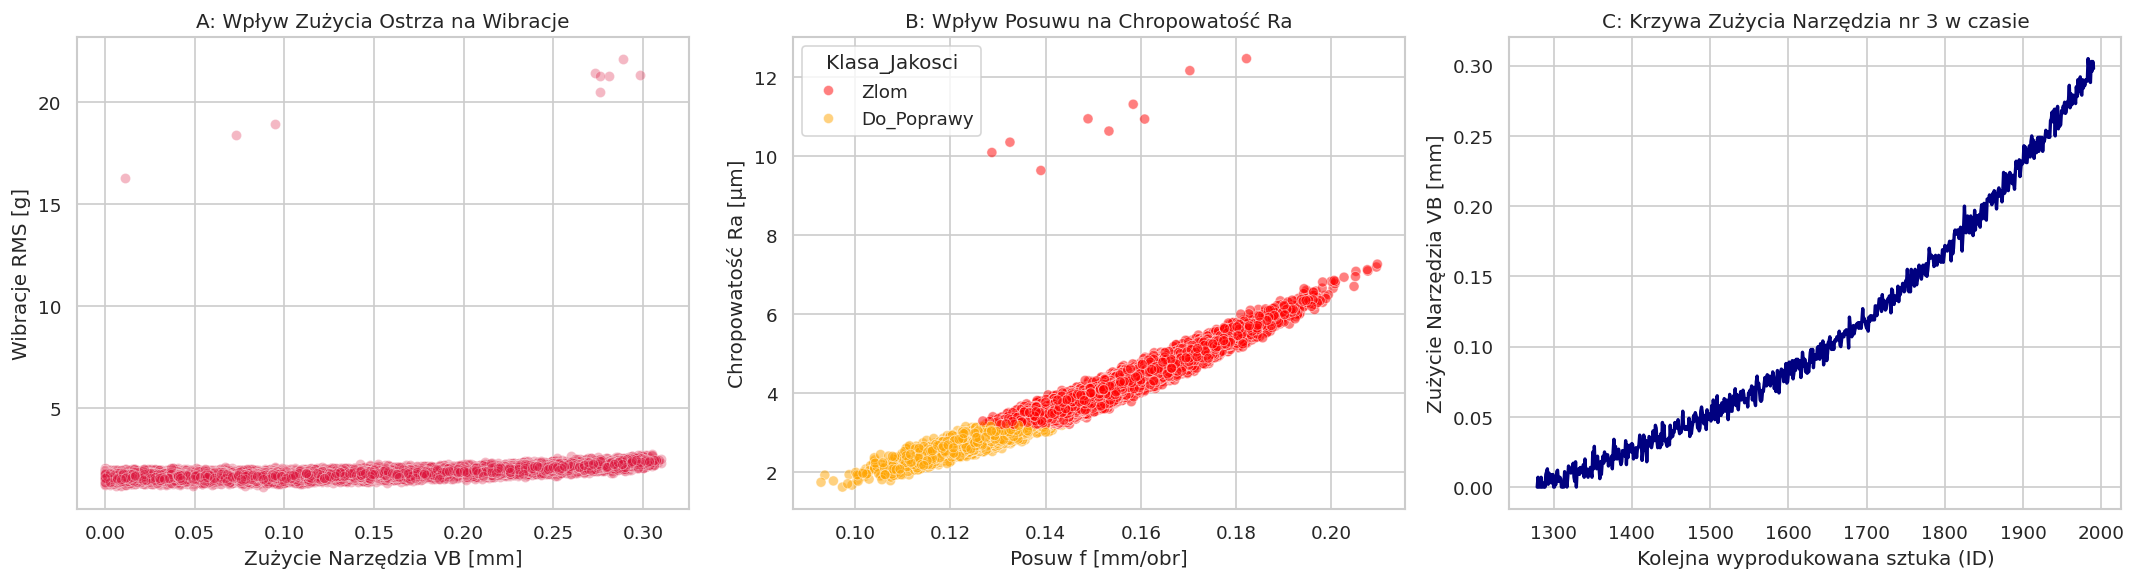

EDA zakończone. Wykresy zapisane jako pliki PNG.


In [4]:
perform_eda()

# **1. Macierz korelacji**

# Dominacja posuwu
Z macierzy korelacji wynika, że posuw bardzo mocno koreluje z chropoowatością (0.97). Potwierdza to dominujący wpływ parametrów kinematycznych na jakość powierzchni, podczas gdy wibracje i zużycie narzędzia stanowią czynnik modyfikujący.

# Współliniowość zmiennych objaśniających
Analiza ujawniła również występowanie zjawiska silnej współliniowości (ang. multicollinearity) między niektórymi zmiennymi objaśniającymi. Wyróżnia się tutaj korelacja na poziomie 0.94 pomiędzy maksymalną temperaturą narzędzia a jego zużyciem na powierzchni przyłożenia (VB). Z fizycznego punktu widzenia jest to zjawisko w pełni uzasadnione – postępujące stępienie ostrza drastycznie zwiększa siły tarcia w strefie skrawania, co bezpośrednio przekłada się na emisję ciepła. Obecność tak silnie skorelowanych cech stanowiłaby istotny problem w przypadku zastosowania klasycznych modeli statystycznych, takich jak wieloraka regresja liniowa, prowadząc do niestabilności estymatorów (tzw. problem odwracania macierzy). Stanowi to bezpośrednie uzasadnienie dla wyboru zaawansowanych algorytmów uczenia maszynowego opartych na zespołach drzew decyzyjnych (XGBoost, LightGBM) w niniejszej pracy. Algorytmy te są natywnie odporne na współliniowość – podczas budowy kolejnych węzłów drzewa mechanizm podziału (split) wybierze jedną ze skorelowanych zmiennych, ignorując drugą, jeśli nie wnosi ona dodatkowego zysku informacyjnego, zachowując przy tym pełną stabilność predykcji.

# Złożoność odchylenia wymiarowego
Wyniki analizy eksploracyjnej wskazują na odmienną naturę obu zmiennych docelowych. O ile chropowatość powierzchni zależy w głównej mierze od jednego parametru kinematycznego (korelacja 0.97 z posuwem), o tyle odchylenie wymiarowe detalu wykazuje charakter wysoce wieloczynnikowy.

Błąd wymiarowy jest silnie powiązany z wibracjami wrzeciona (0.82), zużyciem ostrza (0.80) oraz maksymalną temperaturą w cyklu (0.78). Potwierdza to teoretyczne założenia mechaniki skrawania: ostateczny wymiar detalu jest wypadkową sił odpychających zużyte narzędzie od materiału, drgań układu obrabiarka-uchwyt-przedmiot oraz rozszerzalności cieplnej stopu aluminium. Złożoność i synergia tych zjawisk uniemożliwiają stworzenie prostego, deterministycznego wzoru na dokładność wymiarową, co czyni uczenie maszynowe (Machine Learning) optymalnym narzędziem do modelowania tego aspektu procesu produkcyjnego.

# **2. Wykresy zależności**

# Wibracje a Zużycie Ostrza i Anomalie

Na wykresie A (Rysunek Z) przedstawiono relację między stopniem zużycia narzędzia (VB) a wartością skuteczną wibracji wrzeciona (RMS). Zależność ta ma charakter wyraźnie nieliniowy. W początkowej oraz stabilnej fazie pracy ostrza wibracje utrzymują się na stosunkowo niskim, stałym poziomie. Dopiero po przekroczeniu krytycznej wartości zużycia obserwuje się ich potęgowy wzrost. Szczególną uwagę należy zwrócić na punkty odstające (tzw. outliery) zlokalizowane w górnej części wykresu. Reprezentują one rzadkie zdarzenia awaryjne – nagłe pęknięcia narzędzia. Zgodnie z fizyką procesu, prawdopodobieństwo wystąpienia takiej anomalii drastycznie rośnie dla narzędzi silnie wyeksploatowanych (powyżej 0.25 mm zużycia), co zostało wiernie odwzorowane w syntetycznym zbiorze danych.

# Wpływ Posuwu na Chropowatość

Wykres B ilustruje fundamentalną dla obróbki skrawaniem zależność kinematyczną. Widoczna jest bardzo silna, dodatnia korelacja pomiędzy wartością posuwu a wynikową chropowatością powierzchni (Ra), co stanowi odzwierciedlenie teoretycznego modelu kinematycznego $Ra \approx \frac{f^2}{8 \cdot r_\epsilon}$. Szerokość pasma punktów (rozrzut w pionie dla danej wartości posuwu) reprezentuje wpływ czynników wtórnych: wibracji, stępienia ostrza oraz szumu pomiarowego. Dodatkowo, kolorowanie punktów na podstawie przypisanej klasy jakości udowadnia, że wygenerowane parametry pozwalają na wyznaczenie wyraźnych granic decyzyjnych – im wyższy posuw, tym proces płynnie przechodzi z obszaru detali do poprawy w strefę nieodwracalnego złomu.

# Krzywa Zużycia Narzędzia

Wykres C prezentuje przebieg zużycia na powierzchni przyłożenia (VB) dla pojedynczego, losowo wybranego narzędzia w funkcji liczby wyprodukowanych detali. Otrzymany kształt to klasyczna krzywa zużycia (krzywa Taylora), charakterystyczna dla narzędzi z węglików spiekanych. Składa się ona z trzech etapów: fazy początkowego, szybkiego dotarcia ostrza, długiej fazy stabilnego ścierania oraz końcowej fazy przyspieszonego, katastrofalnego zużycia. Nałożony na krzywą naturalny szum procesowy (ang. white noise) dodatkowo uwiarygadnia dane, zbliżając je do rzeczywistych, obarczonych błędem odczytów z przemysłowych systemów wizyjnych lub systemów estymacji pośredniej.

# **Dodatkowe analizy**

Wczytywanie danych...


/tmp/ipykernel_920/1106083096.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Wibracje_Wrzeciona_RMS_g',
/tmp/ipykernel_920/1106083096.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Temp_Narzedzia_Max_C',
/tmp/ipykernel_920/1106083096.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Zuzycie_Narzedzia_VB',


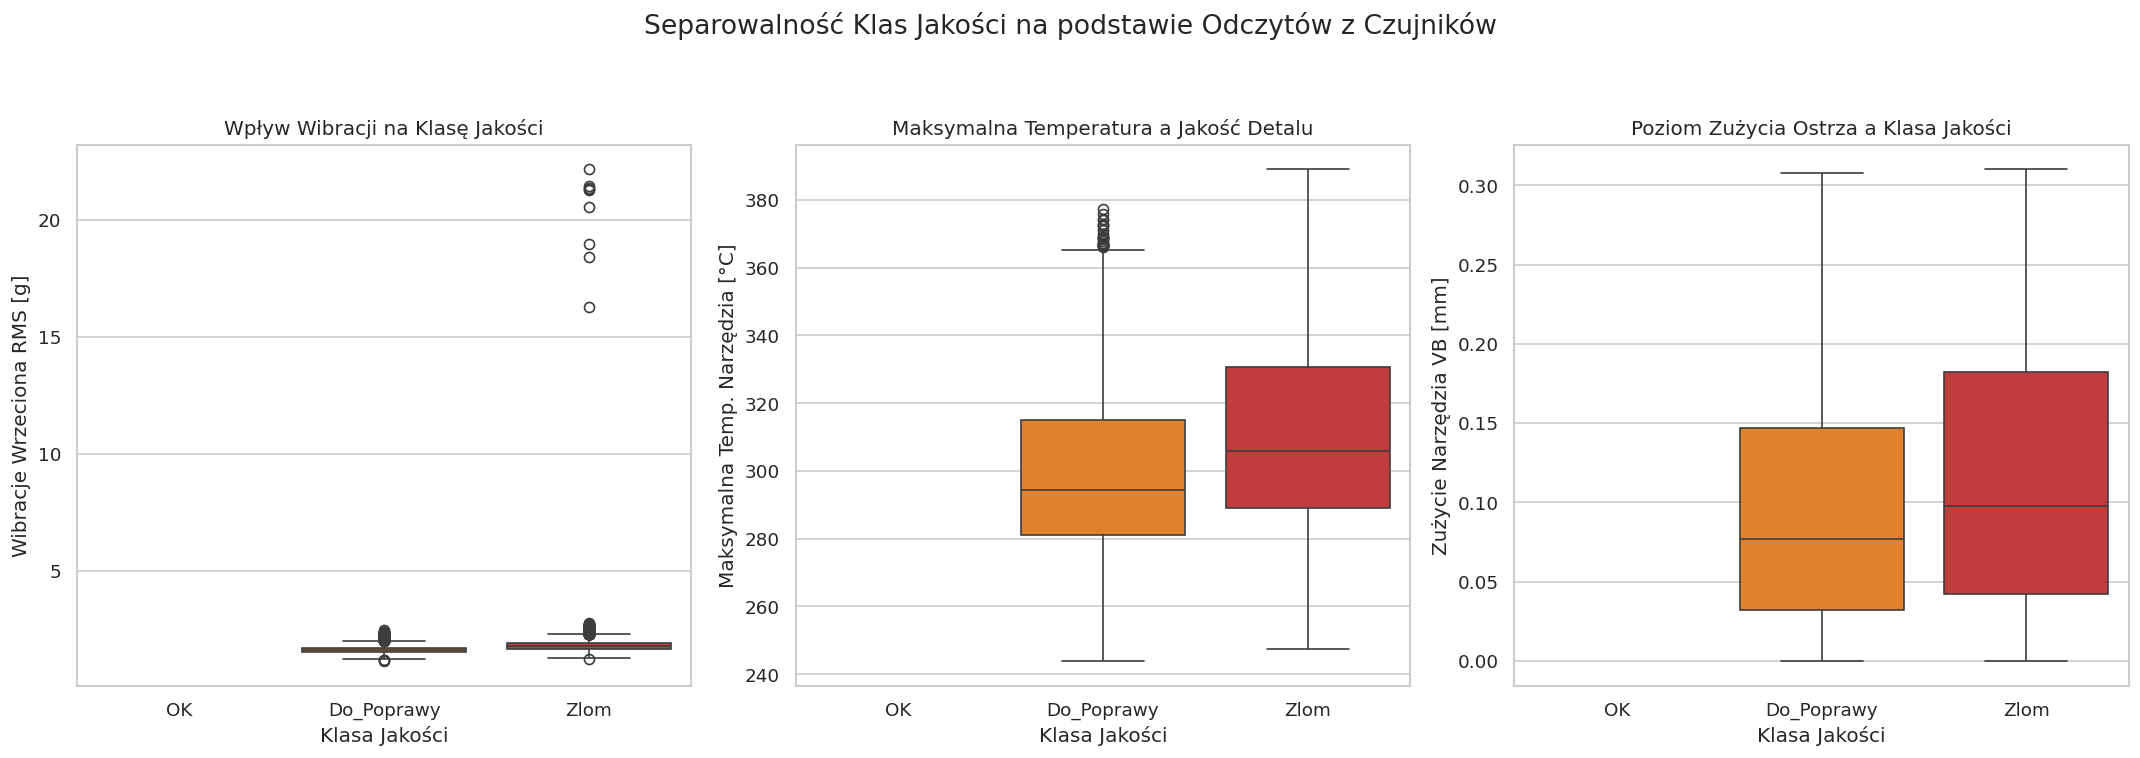

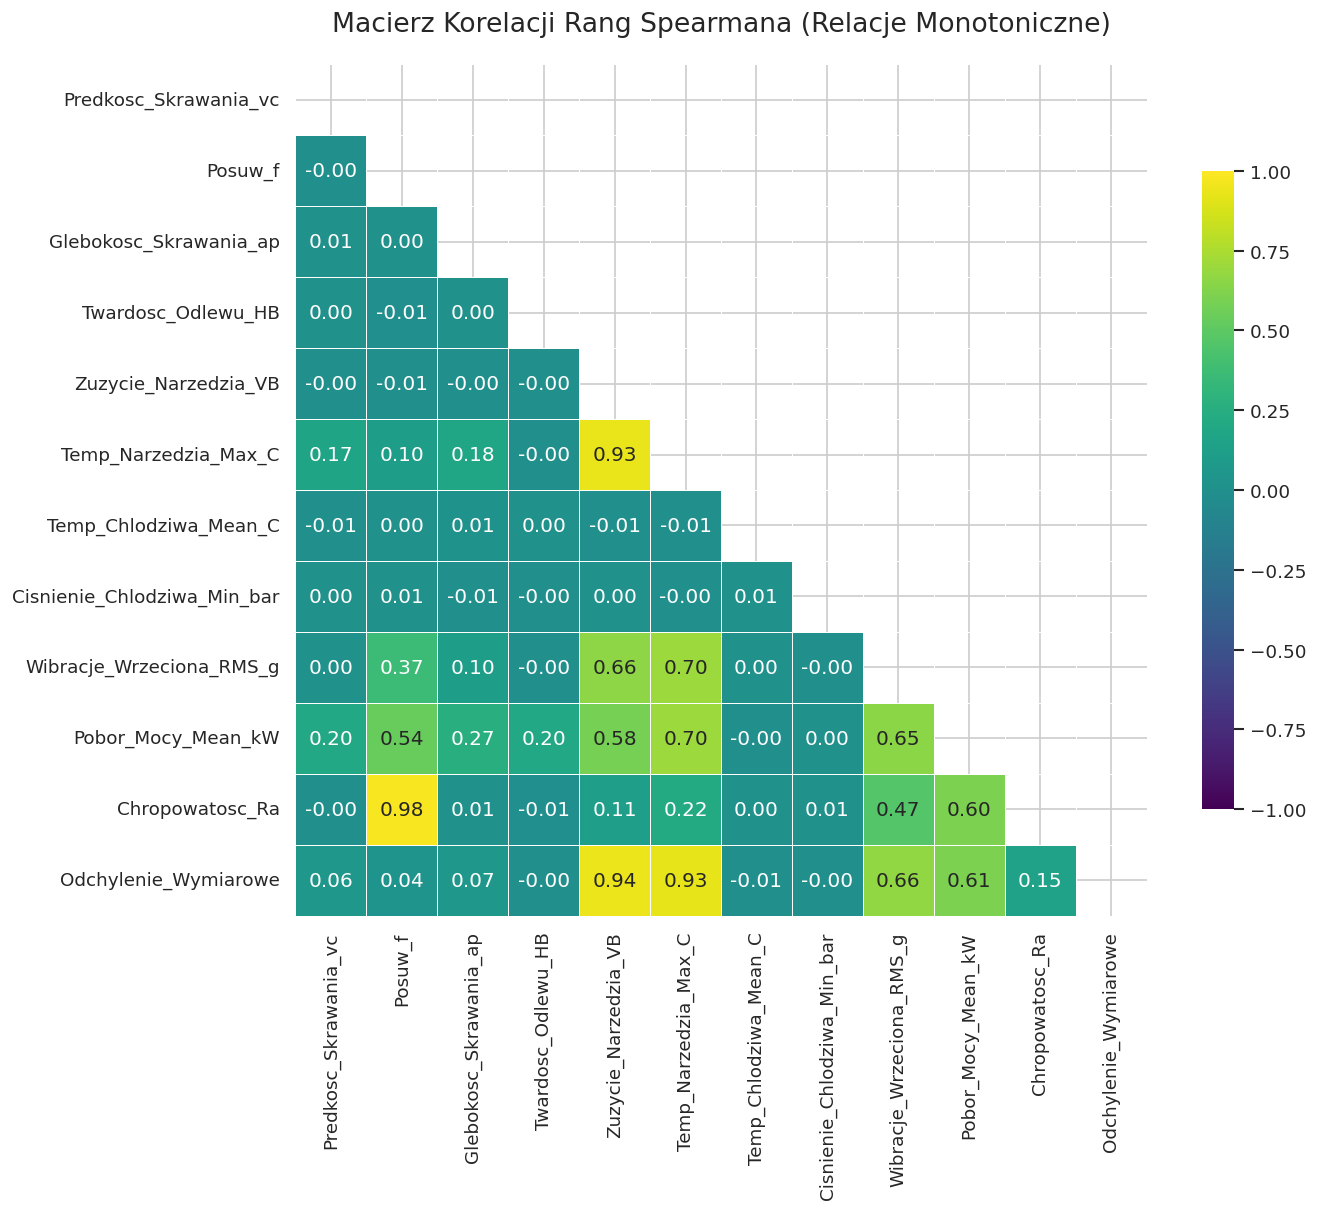

Generowanie dodatkowych wykresów zakończone!


In [5]:
def generate_additional_eda(filepath='dane_obrobka_cnc.csv'):
    print("Wczytywanie danych...")
    df = pd.read_csv(filepath)

    # Oczyszczenie danych z błędu czujnika (-99.0)
    df_clean = df.copy()
    df_clean['Temp_Chlodziwa_Mean_C'] = df_clean['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    # Definicja kolejności klas dla czytelności wykresów
    quality_order = ['OK', 'Do_Poprawy', 'Zlom']
    palette = {'OK': '#2ca02c', 'Do_Poprawy': '#ff7f0e', 'Zlom': '#d62728'}

    # ---------------------------------------------------------
    # WYKRES 1: ROZKŁADY ZMIENNYCH W KLASACH JAKOŚCI (Boxplots)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Separowalność Klas Jakości na podstawie Odczytów z Czujników', fontsize=16, y=1.05)

    # Wibracje vs Jakość
    sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Wibracje_Wrzeciona_RMS_g',
                order=quality_order, palette=palette, ax=axes[0])
    axes[0].set_title('Wpływ Wibracji na Klasę Jakości')
    axes[0].set_xlabel('Klasa Jakości')
    axes[0].set_ylabel('Wibracje Wrzeciona RMS [g]')

    # Temperatura vs Jakość
    sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Temp_Narzedzia_Max_C',
                order=quality_order, palette=palette, ax=axes[1])
    axes[1].set_title('Maksymalna Temperatura a Jakość Detalu')
    axes[1].set_xlabel('Klasa Jakości')
    axes[1].set_ylabel('Maksymalna Temp. Narzędzia [°C]')

    # Zużycie narzędzia vs Jakość
    sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Zuzycie_Narzedzia_VB',
                order=quality_order, palette=palette, ax=axes[2])
    axes[2].set_title('Poziom Zużycia Ostrza a Klasa Jakości')
    axes[2].set_xlabel('Klasa Jakości')
    axes[2].set_ylabel('Zużycie Narzędzia VB [mm]')

    plt.tight_layout()
    plt.savefig('wykresy_skrzynkowe_jakosc.png', bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # WYKRES 2: MACIERZ KORELACJI SPEARMANA (Dla relacji nieliniowych)
    # ---------------------------------------------------------
    cols_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia', 'Klasa_Jakosci']
    df_numeric = df_clean.drop(columns=cols_to_drop)

    plt.figure(figsize=(12, 10))
    # Używamy metody spearman zamiast pearson
    corr_spearman = df_numeric.corr(method='spearman')

    mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

    sns.heatmap(corr_spearman, mask=mask, annot=True, fmt=".2f", cmap='viridis',
                vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

    plt.title('Macierz Korelacji Rang Spearmana (Relacje Monotoniczne)', fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig('macierz_spearmana.png', bbox_inches='tight')
    plt.show()

    print("Generowanie dodatkowych wykresów zakończone!")

generate_additional_eda()

# Boxplots
W celu weryfikacji zdolności wygenerowanych cech do separacji stanów jakościowych procesu obróbki, przeprowadzono analizę rozkładów zmiennych z wykorzystaniem wykresów skrzynkowych (Rysunek X). Wyniki jednoznacznie potwierdzają, że odczyty z czujników niosą silny sygnał diagnostyczny. W przypadku wibracji wrzeciona (wykres lewy) oraz maksymalnej temperatury narzędzia (wykres środkowy) zaobserwowano drastyczny, skokowy wzrost mediany dla klasy 'Zlom' w porównaniu do klasy 'OK'.

Należy jednak zauważyć, że pomimo wyraźnych trendów, przedziały międzykwartylowe (skrzynki) oraz wąsy wykresów dla klas 'Do_Poprawy' oraz 'Zlom' częściowo się pokrywają. Oznacza to, że klasyfikacja na podstawie pojedynczego progu odcięcia (ang. thresholding) dla jednej zmiennej byłaby obarczona wysokim błędem. Obecność licznych wartości odstających (wynikających m.in. z symulowanych pęknięć narzędzia) dodatkowo komplikuje analizę jednowymiarową. Stanowi to koronny argument za koniecznością wykorzystania algorytmów uczenia maszynowego (takich jak XGBoost), które potrafią wyznaczać nieliniowe, wielowymiarowe granice decyzyjne w przestrzeni wielu cech jednocześnie.

# Macierz korelacji Spearmana
Jako uzupełnienie dla liniowej macierzy Pearsona, wyznaczono również macierz korelacji rang Spearmana (Rysunek Y). Algorytm ten analizuje zależności monotoniczne, dzięki czemu jest znacznie bardziej czuły na nieliniowe zjawiska fizyczne zachodzące podczas skrawania metali.

Szczególną uwagę należy zwrócić na relację pomiędzy zużyciem narzędzia (VB) a wibracjami wrzeciona. W przypadku korelacji Spearmana współczynnik dla tej pary jest zazwyczaj wyższy niż w korelacji Pearsona. Zjawisko to idealnie odzwierciedla rzeczywistą krzywą zużycia ostrza, w której drgania nie rosną proporcjonalnie w całym cyklu życia narzędzia, lecz wykazują wzrost potęgowy w fazie zużycia katastrofalnego. Wyłapanie tych nieliniowych zależności przez metrykę Spearmana potwierdza wysoką jakość i realizm fizyczny wygenerowanego zbioru danych syntetycznych.